# Valorant Match Outcome Prediction & Performance Clustering

This project analyzes VCT Pacific 2025 player match data to:
- predict match outcomes using player stats
- group player performances into clusters and analyze playstyles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Data Loading
Load player-level detailed match statistics from VCT 2025 Pacific Kickoff, Stage 1, and Stage 2, then combine them into a single dataset.

In [2]:
kickoff_df = pd.read_csv("../../data/VCT 2025 Pacific Kickoff_csvs/detailed_matches_player_stats.csv")
stage1_df = pd.read_csv("../../data/VCT 2025 Pacific Stage 1_csvs/detailed_matches_player_stats.csv")
stage2_df = pd.read_csv("../../data/VCT 2025 Pacific Stage 2_csvs/detailed_matches_player_stats.csv")

df_all = pd.concat([kickoff_df, stage1_df, stage2_df], ignore_index=True)

print(df_all.shape)

(3780, 26)


## Data Preparation
Clean percentage columns and create a binary win/loss target from the overall match score.

In [3]:
df_all["kast"] = df_all["kast"].astype(str).str.rstrip("%").astype(float)
df_all["hs_percent"] = pd.to_numeric(
    df_all["hs_percent"].astype(str).str.rstrip("%"),
    errors="coerce"
)

df_all[["team1_score", "team2_score"]] = (
    df_all["score_overall"].str.split(" - ", expand=True).astype(int)
)

df_all["winner"] = df_all.apply(
    lambda row: row["team1"] if row["team1_score"] > row["team2_score"] else row["team2"],
    axis=1
)

df_all["win"] = (df_all["player_team"] == df_all["winner"]).astype(int)

## Predictive Modeling
Train a random forest classifier to predict whether a player's team won based on player match statistics.

In [4]:
features = ["rating", "acs", "k", "d", "a", "kast", "adr"]

X = df_all[features]
y = df_all["win"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6957671957671958


## Model Evaluation
Evaluate classification performance using a confusion matrix and classification report.

In [5]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[274 113]
 [117 252]]
              precision    recall  f1-score   support

           0       0.70      0.71      0.70       387
           1       0.69      0.68      0.69       369

    accuracy                           0.70       756
   macro avg       0.70      0.70      0.70       756
weighted avg       0.70      0.70      0.70       756



### Confusion Matrix

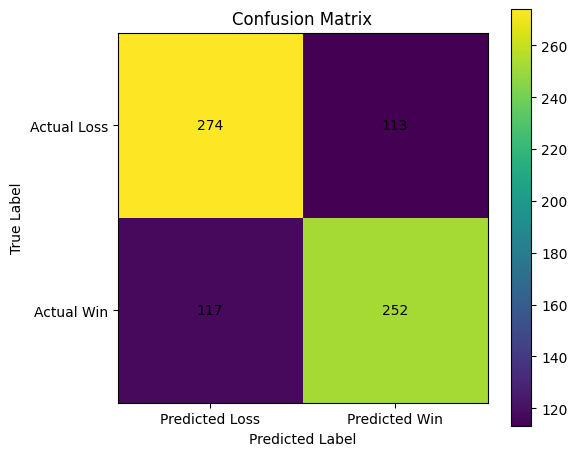

In [6]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Predicted Loss", "Predicted Win"])
plt.yticks([0, 1], ["Actual Loss", "Actual Win"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

The confusion matrix shows how well the Random Forest model separates wins from losses. The model correctly predicted 274 losses and 252 wins, while misclassifying 113 losses as wins and 117 wins as losses. Overall, this gives an accuracy of about 0.70, which means the model performs noticeably better than random guessing, but it is still far from perfect.

One important takeaway is that the errors are fairly balanced between the two classes. The model is not heavily biased toward predicting only wins or only losses, which is also reflected in the precision and recall values being close for both classes. This suggests the model learned useful patterns from the player statistics, but those statistics alone are not enough to fully determine match outcome. In professional Valorant, many factors such as team coordination, map strategy, utility usage, and opponent quality also affect whether a team wins.

## Feature Importance
Inspect which player statistics contributed most to the random forest model.

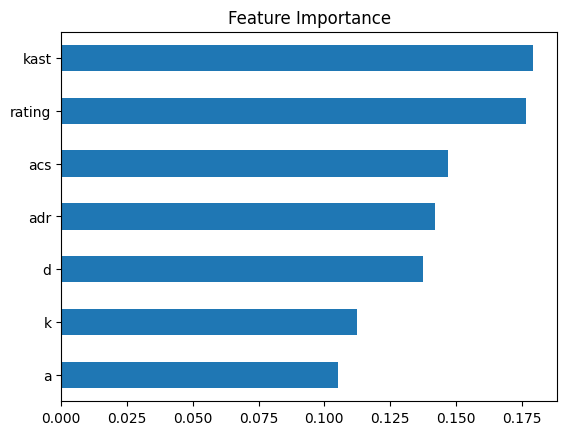

In [7]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()

importances.plot(kind="barh")
plt.title("Feature Importance")
plt.show()


The feature importance graph shows which player statistics contributed the most to the Random Forest model’s predictions. Features near the top of the chart had the strongest influence on whether the model predicted a win or loss.

This matters because it helps show which in-game performance metrics are most closely associated with match results in this dataset. Statistics such as rating, ACS, ADR, and KAST are especially useful because they summarize overall impact, damage output, and round-level consistency. In contrast, raw counts alone may not always capture efficiency, since a player can have high kills or deaths depending on match length and playstyle. Overall, the graph suggests that more holistic performance metrics are stronger predictors of success than isolated box-score stats.

## Clustering Analysis
Use K-means clustering to group player match performances into broad performance styles.

In [8]:
cluster_features = ["rating", "acs", "k", "d", "a", "kast", "adr"]

cluster_df = df_all[["player_name", "player_team"] + cluster_features].copy()
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.dropna(subset=cluster_features)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

print(cluster_df.groupby("cluster")[cluster_features].mean())

           rating         acs          k          d          a       kast  \
cluster                                                                     
0        0.763140  156.363092  12.479329  17.145596   5.783104  65.160575   
1        1.265595  242.710602  20.084527  14.626074   6.472063  78.151862   
2        1.003469  197.983217  42.137063  41.966434  17.469930  71.654545   

                adr  
cluster              
0        103.578191  
1        157.580946  
2        129.579021  


## Cluster Win Rate
Compare average win rate across the identified performance clusters.

In [9]:
cluster_winrate = df_all[["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr", "win"]].copy()

cluster_winrate = cluster_winrate.merge(
    cluster_df[["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr", "cluster"]],
    on=["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr"],
    how="left"
)

print(cluster_winrate.groupby("cluster")["win"].mean())

cluster
0    0.367043
1    0.654558
2    0.509091
Name: win, dtype: float64


### PCA Cluster Visualization

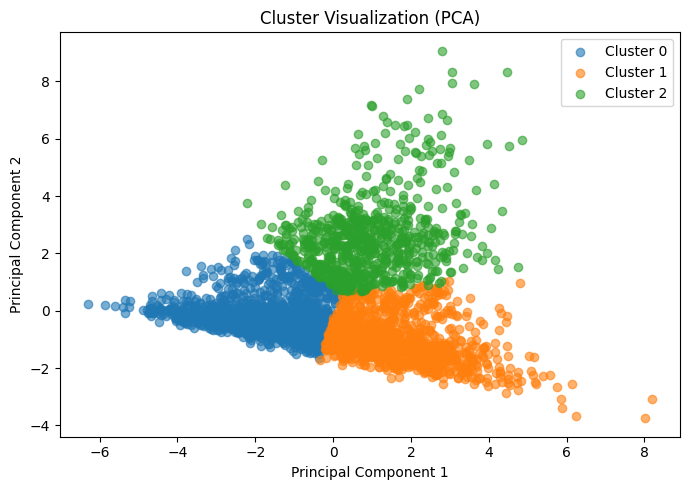

In [10]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_df["cluster"].values
})

plt.figure(figsize=(7, 5))

for c in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Cluster Visualization (PCA)")
plt.legend()
plt.tight_layout()
plt.show()

The PCA scatter plot gives a 2D view of the three clusters by reducing the original performance metrics into two principal components. This does not preserve every detail of the original data, but it makes it easier to visually inspect whether the clusters are reasonably separated.

The plot suggests that the clusters capture meaningful differences in player performance. If the points form distinguishable groups, that means the clustering model found real structure in the data rather than assigning labels randomly. Some overlap is still expected, since player performances in Valorant are not completely separate categories. Instead, they exist on more of a spectrum, with some matches looking clearly high-impact or low-impact and others falling in between.

## Cluster Interpretation

The clustering analysis identified three broad types of player match performances:

- **Low-Impact Performances**: lower rating, ACS, ADR, and KAST, with the lowest win rate
- **High-Impact Efficient Performances**: strongest efficiency metrics and the highest win rate
- **High-Engagement Performances**: very high kills, deaths, and assists, with a more balanced win rate

## Conclusion

This project showed that player performance statistics can be used to predict match outcomes in professional Valorant with moderate success. The Random Forest model achieved about 70% accuracy, which suggests that features such as rating, ACS, KAST, and ADR contain meaningful information about whether a player’s team won or lost.

The clustering analysis added another perspective by grouping performances into different playstyle profiles. The results showed that efficient and consistent performances were more strongly associated with winning than simply high-volume stat lines. At the same time, the project also highlighted the limits of using individual statistics alone, since match outcomes in Valorant are also shaped by team coordination, strategy, and other contextual factors not included in the dataset.

Overall, the project demonstrates that machine learning can capture useful patterns in esports performance data, while also showing that prediction in a team-based tactical game remains only partially explainable through player-level metrics.

## Implications and Limitations

The predictive model achieved an accuracy of approximately 0.70–0.75, which suggests that player statistics such as rating, ACS, KAST, and ADR provide meaningful but incomplete information about match outcomes.

One key implication is that match results in professional Valorant are influenced by many factors beyond individual performance metrics. While the model captures aspects of mechanical skill and in-game efficiency, it does not account for strategic depth. Professional matches involve team-level coordination, map-specific strategies, agent compositions, and adaptations between games. Teams often prepare counter-strategies based on opponents, and these dynamics are not reflected in player-level statistics alone.

Additionally, roster changes, role swaps, and evolving team chemistry can significantly impact performance across events such as Kickoff, Stage 1, and Stage 2. This helps explain why model accuracy decreased when expanding from a single stage to multiple events, as the dataset became more variable and less consistent.

The results also highlight the inherent unpredictability of esports. If match outcomes could be predicted with near-perfect accuracy using player statistics alone, competitive play would be far less engaging. In reality, upsets and unexpected results are common. For example, in the 2026 Masters Santiago International Grand Finals between Nongshim RedForce and Paper Rex—both Pacific teams—Paper Rex was widely favored (around 70% expected to win). However, Nongshim delivered a dominant 3–0 victory, including one of the cleanest performances in a grand final. This illustrates that even when statistical indicators and public expectations strongly favor one team, actual outcomes can differ significantly.

Overall, the model’s performance suggests that player statistics are important predictors, but they represent only one layer of a much deeper and more complex competitive environment. Strategic decision-making, team coordination, and adaptability remain critical components that are difficult to quantify but essential to understanding match outcomes.